# Alternative 1: standalone HDBSCAN clustering and evaluation

Use P1 Alternative 1 area and perimeter only, standardise, then apply HDBSCAN without specifying a target number of clusters. No PCA, CNN or other clustering model is used. P1 inputs and existing notebooks remain unchanged.

This notebook separates three questions: how many groups are found; whether their count profile agrees with the supplied manual counts; and whether individual objects are correctly grouped. Only independent object-level labels can answer the last question. Internal separation, membership strength and stability are not classification accuracy.

## Human review update (14 September 2026)

The user reports visually checking every extracted candidate against the reference and confirming all 248 classifications. The label file was transcribed from these confirmed groups: C1=P3, C2=P2, C3=Dimer of P1, C4=Trimer of P1, C5=Tetramer of P1. This is **prediction-assisted human review**, not independent blind ground truth or held-out evaluation. Agreement charts below must be interpreted under this limitation.

The user additionally reports 8 dimers, 1 trimer and 1 tetramer excluded at the border, and 3 overlapping P2 molecules not individually counted. They do not have candidate IDs in the current output. These 13 objects are not HDBSCAN noise: all 248 extracted candidates are assigned. Missing-object coordinates have not been provided, so the full-image result below is count recovery from reported totals, not independently spatially matched detection recall.


## 1. Input and configuration

Load the candidate table, object positions, label image and corrected height image. Only area (nm^2) and perimeter (nm) enter fitting, selection and stability analysis. Height is used solely as the background of diagnostic plots. Record hashes and align all tables by object ID.



In [1]:
from pathlib import Path
import json, hashlib, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_samples
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits
import sklearn

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'Project_Data').is_dir() and (p/'Notebooks').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Run this notebook inside the extracted Formal package.')
P1 = ROOT/'Notebooks/P1/outputs/alternative_1_plane_fitting'
OUT = ROOT/'Notebooks/P3/outputs/alternative1_hdbscan_standalone'
OUT.mkdir(parents=True, exist_ok=True)
FEATURES = ['area_nm2','perimeter_nm']
SEED, K_MAX = 42, 10
STABILITY_REPEATS, SAMPLE_FRACTION = 20, 0.8
MIN_CLUSTER_SIZE, MIN_SAMPLES = 10, 5
def sha(path): return hashlib.sha256(path.read_bytes()).hexdigest()
INPUTS = ['candidate_features.csv','object_index.csv','label_image.npy','corrected_height.npy']
input_hashes = {name:sha(P1/name) for name in INPUTS}
features = pd.read_csv(P1/'candidate_features.csv')
objects = pd.read_csv(P1/'object_index.csv')
assert features.object_id.is_unique and objects.object_id.is_unique
assert set(features.object_id) == set(objects.object_id)
features = features.sort_values('object_id').reset_index(drop=True)
objects = objects.set_index('object_id').loc[features.object_id].reset_index()
ids = features.object_id.to_numpy(dtype=int)
raw = features[FEATURES].to_numpy(dtype=float)
assert np.isfinite(raw).all(), 'Resolve invalid P1 features before running this comparison.'
assert (np.std(raw,axis=0)>0).all(), 'A constant feature requires review.'
label_image = np.load(P1/'label_image.npy')
height = np.load(P1/'corrected_height.npy')
assert height.shape == label_image.shape
assert set(np.unique(label_image)) - {0} == set(ids)
scaler = StandardScaler()
X = scaler.fit_transform(raw)
max_k = min(K_MAX,len(ids)-1,len(np.unique(X,axis=0)))
assert max_k >= 2
assert FEATURES == ['area_nm2','perimeter_nm']
assert X.shape[1] == 2
np.save(OUT/'standardized_features.npy',X)
np.savez(OUT/'standardization.npz',mean=scaler.mean_,scale=scaler.scale_,features=np.array(FEATURES))
display(features[["object_id", *FEATURES]].head())
print('Candidates:',len(ids),'Features:',len(FEATURES),'Search maximum:',max_k)


,object_id,area_nm2,perimeter_nm
0,1,1.751709,4.774430
1,2,4.144287,7.937342
2,3,2.105713,5.418386
3,4,4.010010,7.830109
4,5,1.690674,4.709709


Candidates: 248 Features: 2 Search maximum: 10


## 2. Direct area-perimeter diagnostics

The scatter plot shows original area and perimeter, not transformed axes. Each point is one candidate region. The correlation heat map shows whether the two features largely encode the same size variation. Clustering operates on their standardised values to avoid allowing a numerical unit scale to dominate distance.


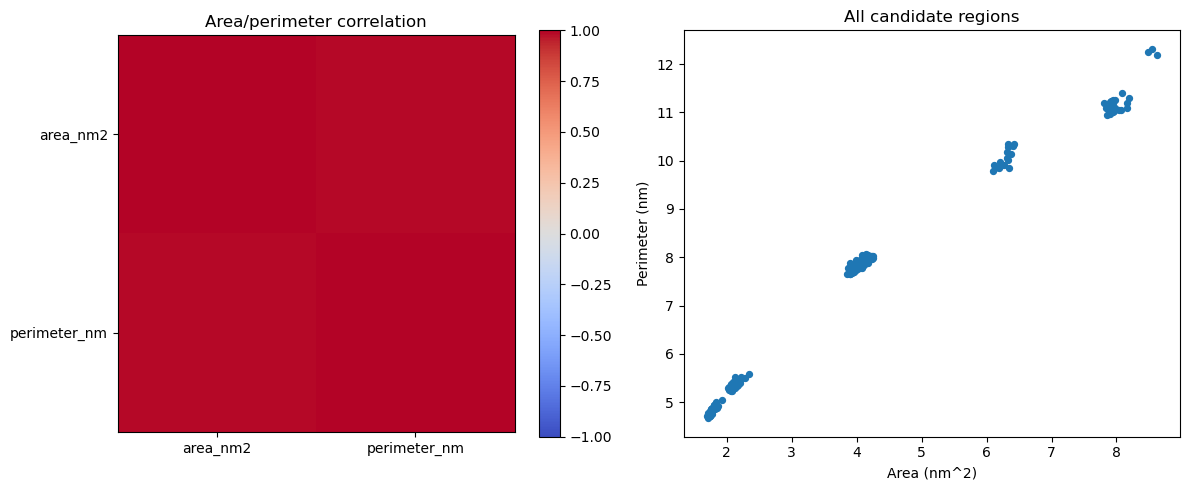

In [2]:
fig,axes = plt.subplots(1,2,figsize=(12,5))
correlation = features[FEATURES].corr()
im = axes[0].imshow(correlation,vmin=-1,vmax=1,cmap='coolwarm')
axes[0].set_xticks(range(len(FEATURES)),FEATURES)
axes[0].set_yticks(range(len(FEATURES)),FEATURES)
axes[0].set_title('Area/perimeter correlation')
fig.colorbar(im,ax=axes[0])
axes[1].scatter(raw[:,0],raw[:,1],s=18)
axes[1].set(xlabel='Area (nm^2)',ylabel='Perimeter (nm)',title='All candidate regions')
fig.tight_layout()
fig.savefig(OUT/'area_perimeter_diagnostics.png',dpi=160)
plt.show()


## 3. HDBSCAN fitting

Keep the existing settings: min_cluster_size=10 and min_samples=5 (scikit-learn HDBSCAN). The algorithm discovers groups from density; no target k is supplied. Label -1 means unassigned. These parameters still affect the result and are not proof that a discovered group is a chemical category.

In [3]:
def fit_labels(name, config, matrix, seed=SEED):
    return HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES).fit_predict(matrix)

model = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES)
labels = model.fit_predict(X)
results = {'HDBSCAN': labels}
configs = {'HDBSCAN': {'min_cluster_size': MIN_CLUSTER_SIZE, 'min_samples': MIN_SAMPLES,
                       'selection': 'density persistence', 'boundary': False}}
print('Discovered groups:', len(set(labels)-{-1}), 'Unassigned:', int((labels<0).sum()))


Discovered groups: 5 Unassigned: 0


## 4. Internal quality and conditional stability

Report silhouette, Calinski-Harabasz (higher), Davies-Bouldin (lower), group sizes and assigned coverage. HDBSCAN scores exclude noise and therefore are **not directly comparable** with full-coverage scores. Noise counts are reported separately.

For stability, sample 80% of objects 20 times, refit the scaler on each subset, and recluster with the selected configuration. Compare subset labels with the full-run labels using adjusted Rand index (ARI). This tests stability **conditional on the selected settings**, not stability of automatic k selection. For HDBSCAN, compare only objects assigned in both runs and report the fraction compared. Stability and internal quality do not establish chemical accuracy.


In [4]:
summary_rows, stability_rows = [], []
rng = np.random.default_rng(SEED)
subsets = [np.sort(rng.choice(len(ids),size=int(len(ids)*SAMPLE_FRACTION),replace=False))
           for _ in range(STABILITY_REPEATS)]
for name,labels in results.items():
    valid=labels>=0
    groups=np.unique(labels[valid]); counts=pd.Series(labels[valid]).value_counts()
    measurable=1<len(groups)<valid.sum()
    summary_rows.append(dict(method=name,n_candidates=len(ids),n_groups=len(groups),
        n_unassigned=int((~valid).sum()),coverage=float(valid.mean()),
        silhouette=float(silhouette_score(X[valid],labels[valid])) if measurable else np.nan,
        calinski_harabasz=float(calinski_harabasz_score(X[valid],labels[valid])) if measurable else np.nan,
        davies_bouldin=float(davies_bouldin_score(X[valid],labels[valid])) if measurable else np.nan,
        min_group_size=int(counts.min()) if len(counts) else 0,
        max_group_size=int(counts.max()) if len(counts) else 0,
        selection_boundary=configs[name]['boundary']))
    with threadpool_limits(limits=1):
        for repeat,subset in enumerate(subsets):
            try:
                subset_x=StandardScaler().fit_transform(raw[subset])
                predicted=fit_labels(name,configs[name],subset_x,SEED+repeat+1)
                reference=labels[subset]
                compared=(predicted>=0)&(reference>=0)
                meaningful=(compared.sum()>2 and len(np.unique(predicted[compared]))>1
                            and len(np.unique(reference[compared]))>1)
                ari=float(adjusted_rand_score(reference[compared],predicted[compared])) if meaningful else np.nan
                stability_rows.append(dict(method=name,repeat=repeat,ari=ari,
                    compared_fraction=float(compared.mean()),status='ok' if meaningful else 'insufficient_groups'))
            except (ValueError,np.linalg.LinAlgError) as error:
                stability_rows.append(dict(method=name,repeat=repeat,ari=np.nan,
                    compared_fraction=np.nan,status=str(error)))
summary=pd.DataFrame(summary_rows)
stability=pd.DataFrame(stability_rows)
stats=stability.groupby('method').agg(stability_ari_mean=('ari','mean'),stability_ari_std=('ari','std'),
    successful_stability_runs=('ari','count'),stability_compared_fraction=('compared_fraction','mean'))
summary=summary.merge(stats,on='method')
summary.to_csv(OUT/'algorithm_comparison.csv',index=False)
stability.to_csv(OUT/'subsample_stability.csv',index=False)
display(summary)
full=summary[(summary.coverage==1)&summary.silhouette.notna()]
if len(full):
    print('Highest full-coverage silhouette:',full.loc[full.silhouette.idxmax(),'method'])
print('This is an INTERNAL-score comparison, not a classification-accuracy ranking.')


,method,n_candidates,n_groups,n_unassigned,coverage,silhouette,calinski_harabasz,davies_bouldin,min_group_size,max_group_size,selection_boundary,stability_ari_mean,stability_ari_std,successful_stability_runs,stability_compared_fraction
0,HDBSCAN,248,5,0,1.0,0.877585,14590.854729,0.214574,16,106,False,1.0,0.0,20,1.0


Highest full-coverage silhouette: HDBSCAN
This is an INTERNAL-score comparison, not a classification-accuracy ranking.


## 5. Classification overlays, counts and representative candidates

Assign C1, C2, ... in ascending mean area **after fitting**, solely for readable plots. C1 in one method need not match C1 in another. Grey objects are unassigned, not missing detections. Export one row per original object, including unassigned objects. Display representative crops nearest each group's centroid in the two-dimensional standardised area/perimeter space; representatives are not a correctness check for every object.


,group_id,group_label,candidate_count,method
0,1,C1,32,HDBSCAN
1,2,C2,67,HDBSCAN
2,3,C3,106,HDBSCAN
3,4,C4,16,HDBSCAN
4,5,C5,27,HDBSCAN


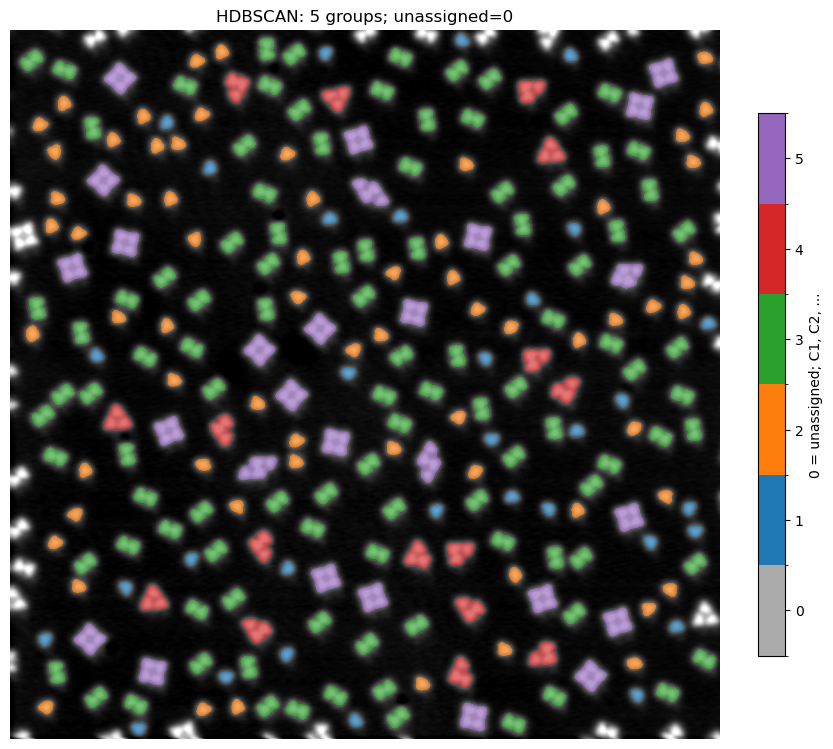

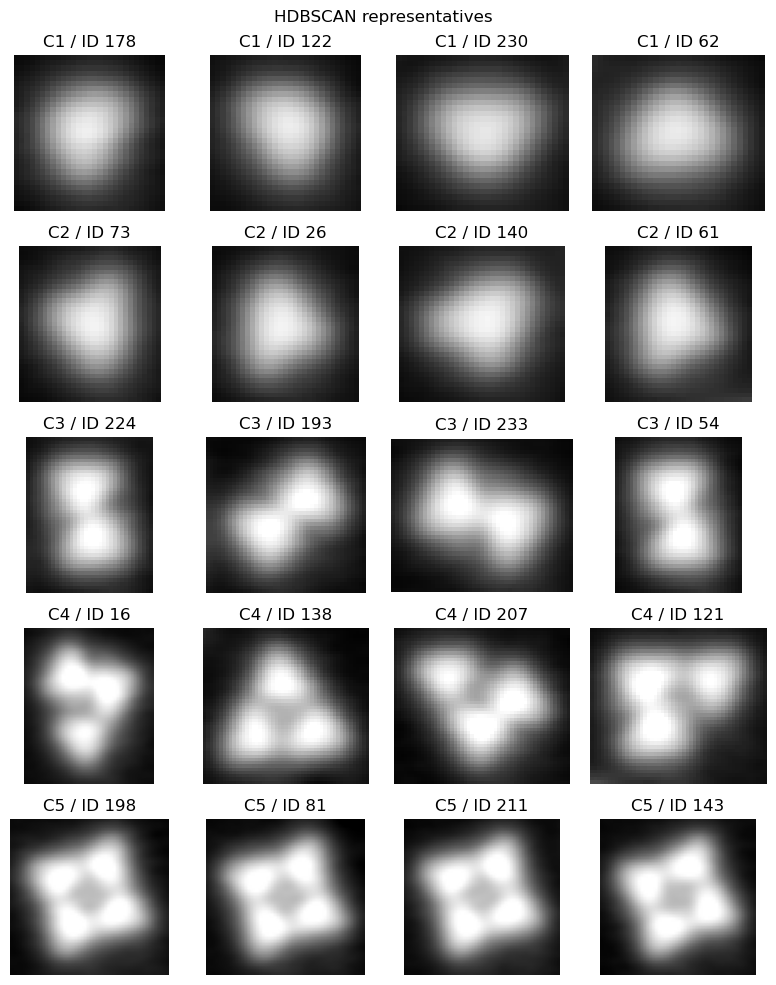

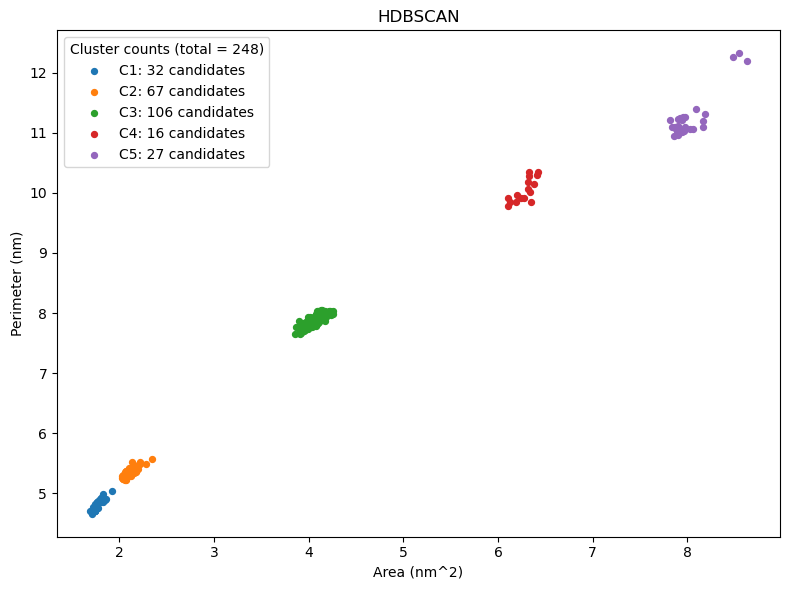

In [5]:
assignments_all=[]
fig,axes=plt.subplots(1,1,figsize=(10,10),squeeze=False)
lo,hi=np.nanpercentile(height,[1,99])
for ax,(name,labels) in zip(axes.flat,results.items()):
    groups=sorted(set(labels)-{-1},key=lambda g:raw[labels==g,0].mean())
    mapping={g:i+1 for i,g in enumerate(groups)}
    readable=np.array([mapping.get(g,0) for g in labels])
    lookup=np.zeros(int(label_image.max())+1,dtype=int)
    lookup[ids]=readable
    cluster_map=lookup[label_image]
    np.save(OUT/f'{name}_cluster_image.npy',cluster_map)
    colors=['#aaaaaa']+[plt.get_cmap('tab10')(i%10) for i in range(len(groups))]
    cmap=ListedColormap(colors); norm=BoundaryNorm(np.arange(-.5,len(groups)+1.5),cmap.N)
    ax.imshow(height,cmap='gray',vmin=lo,vmax=hi)
    ax.imshow(np.ma.masked_where(label_image==0,cluster_map),cmap=cmap,norm=norm,alpha=.65)
    ax.set_title(f'{name}: {len(groups)} groups; unassigned={(labels<0).sum()}')
    ax.axis('off')
    fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cmap),ax=ax,fraction=.035,
                 ticks=range(len(groups)+1),label='0 = unassigned; C1, C2, ...')
    table=objects[['object_id','centroid_row','centroid_col']].copy()
    table['method']=name; table['raw_cluster_id']=labels; table['group_id']=readable
    table['group_label']=['Unassigned' if g==0 else f'C{g}' for g in readable]
    table.to_csv(OUT/f'{name}_assignments.csv',index=False); assignments_all.append(table)
    counts=table.groupby(['group_id','group_label']).size().reset_index(name='candidate_count')
    assert counts.candidate_count.sum()==len(ids)
    counts.to_csv(OUT/f'{name}_counts.csv',index=False)
    display(counts.assign(method=name))
    if groups:
        repfig,repaxes=plt.subplots(len(groups),4,figsize=(8,2*len(groups)),squeeze=False)
        for row,g in enumerate(groups):
            indexes=np.flatnonzero(labels==g)
            center=X[indexes].mean(axis=0)
            nearest=indexes[np.argsort(np.linalg.norm(X[indexes]-center,axis=1))[:4]]
            for col,a in enumerate(repaxes[row]):
                a.axis('off')
                if col>=len(nearest): continue
                index=nearest[col]; obj=objects.iloc[index]
                r0,c0=max(0,int(obj.min_row)-5),max(0,int(obj.min_col)-5)
                r1,c1=min(height.shape[0],int(obj.max_row)+5),min(height.shape[1],int(obj.max_col)+5)
                a.imshow(height[r0:r1,c0:c1],cmap='gray',vmin=lo,vmax=hi)
                a.set_title(f'C{mapping[g]} / ID {ids[index]}')
        repfig.suptitle(name+' representatives'); repfig.tight_layout()
        repfig.savefig(OUT/f'{name}_representatives.png',dpi=140); plt.show()
fig.tight_layout(); fig.savefig(OUT/'all_classification_overlays.png',dpi=160); plt.show()
assignments=pd.concat(assignments_all,ignore_index=True)
assignments.to_csv(OUT/'all_assignments.csv',index=False)
fig,axes=plt.subplots(1,1,figsize=(8,6),squeeze=False)
for ax,(name,labels) in zip(axes.flat,results.items()):
    table=assignments[assignments.method==name].set_index('object_id').loc[ids]
    readable=table.group_id.to_numpy()
    n_groups=int(readable.max())
    colors=['#aaaaaa']+[plt.get_cmap('tab10')(i%10) for i in range(n_groups)]
    cmap=ListedColormap(colors)
    norm=BoundaryNorm(np.arange(-.5,n_groups+1.5),cmap.N)
    for group_id in sorted(np.unique(readable)):
        selected = readable == group_id
        group_name = 'Unassigned' if group_id == 0 else f'C{group_id}'
        ax.scatter(raw[selected,0],raw[selected,1],color=colors[group_id],s=18,
                   label=f'{group_name}: {int(selected.sum())} candidates')
    ax.legend(title=f'Cluster counts (total = {len(readable)})',loc='upper left',frameon=True)
    ax.set(title=name,xlabel='Area (nm^2)',ylabel='Perimeter (nm)')
fig.tight_layout(); fig.savefig(OUT/'all_area_perimeter_scatter.png',dpi=160); plt.show()


## 6. Internal quality plots (not accuracy)

The silhouette plot measures separation in the standardised two-feature space, excluding unassigned objects. Membership strength describes association with the fitted density cluster, not probability of the correct chemical identity. Subsample ARI measures consistency under the existing fixed settings; always read it together with compared coverage.

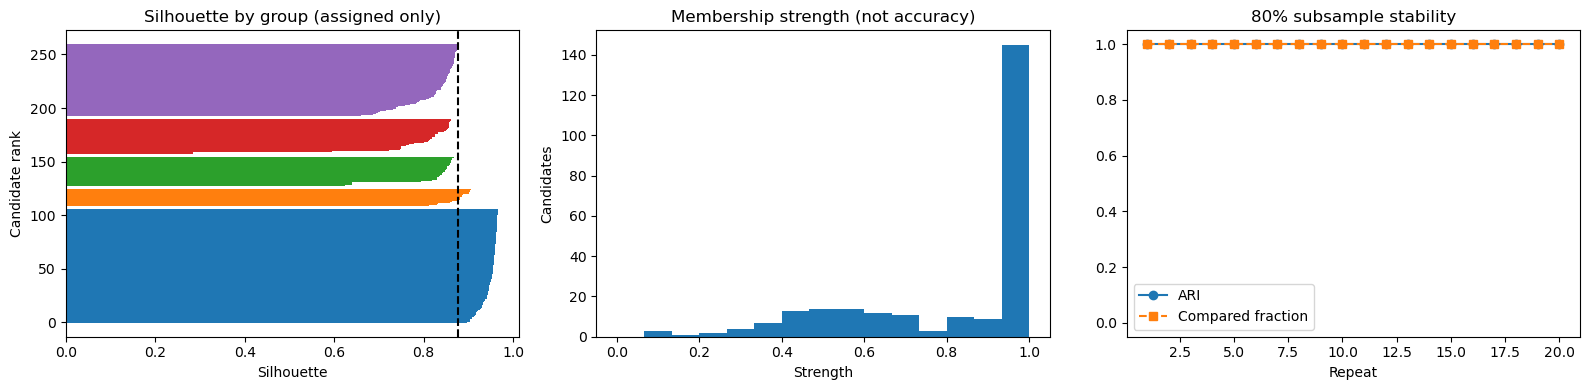

In [6]:
fig, axes = plt.subplots(1,3,figsize=(16,4))
valid = labels >= 0
if 1 < len(set(labels[valid])) < valid.sum():
    scores = silhouette_samples(X[valid], labels[valid])
    offset = 0
    for group in sorted(set(labels[valid])):
        values = np.sort(scores[labels[valid] == group])
        axes[0].barh(np.arange(offset, offset+len(values)), values, height=1)
        offset += len(values)+3
    axes[0].axvline(scores.mean(), color='black', linestyle='--')
axes[0].set(title='Silhouette by group (assigned only)', xlabel='Silhouette', ylabel='Candidate rank')
axes[1].hist(model.probabilities_, bins=15, range=(0,1))
axes[1].set(title='Membership strength (not accuracy)', xlabel='Strength', ylabel='Candidates')
axes[2].plot(stability['repeat']+1, stability.ari, 'o-', label='ARI')
axes[2].plot(stability['repeat']+1, stability.compared_fraction, 's--', label='Compared fraction')
axes[2].set(title='80% subsample stability', xlabel='Repeat', ylim=(-0.05,1.05))
axes[2].legend()
fig.tight_layout(); fig.savefig(OUT/'internal_quality.png', dpi=180); plt.show()


## 6. Manual reference counts and optional object-level evaluation

The reference below is supplied by the user, not newly independently annotated. It distinguishes interior counts, ten border objects and three overlapping P2 objects. The interior reference totals 248, but matching this total does **not** establish that P1 detected exactly the same objects.

Only if a method produces five occupied groups with no unassigned objects do we compare its sorted count profile with the sorted interior reference. The pairing minimises aggregate count discrepancy and is **not a chemical label mapping or accuracy estimate**. Other outcomes remain not comparable under this narrow five-group count-profile test.

For actual object-level evaluation, optionally provide `Notebooks/P3/manual_labels_alternative1.csv` with unique `object_id,true_label` rows. Independently annotate labels before consulting model predictions. Only labelled objects are evaluated, and the coverage is reported. ARI/NMI compare partitions without requiring group names. One-to-one mapped agreement uses a best mapping on these same evaluation labels and is descriptive, not held-out predictive accuracy. Noise counts as incorrect for mapped agreement.


Candidate IDs are specific to this preprocessing method. Never reuse labels from another method without spatial matching. Border/overlap inclusion rules may differ from the interior manual reference.


In [7]:
reference=pd.DataFrame({
    'class':['Dimer of P1','Trimer of P1','Tetramer of P1','P2','P3'],
    'interior_count':[106,16,27,67,32], 'border_count':[8,1,1,0,0],
    'overlap_additional_count':[0,0,0,3,0]})
reference['inclusive_count']=reference[['interior_count','border_count','overlap_additional_count']].sum(axis=1)
reference.to_csv(OUT/'manual_reference_counts.csv',index=False)
display(reference)
reference_profile=np.sort(reference.interior_count.to_numpy())
count_rows=[]
for name,labels in results.items():
    counts=pd.Series(labels[labels>=0]).value_counts().to_numpy()
    comparable=len(counts)==5 and (labels>=0).all()
    count_rows.append(dict(method=name,comparable_five_group_profile=comparable,
        sorted_count_absolute_error=int(np.abs(np.sort(counts)-reference_profile).sum()) if comparable else np.nan,
        candidate_total_difference=int(len(ids)-reference.interior_count.sum())))
display(pd.DataFrame(count_rows))
pd.DataFrame(count_rows).to_csv(OUT/'aggregate_count_reference_comparison.csv',index=False)
manual_path=ROOT/'Notebooks/P3/manual_labels_alternative1.csv'
pd.DataFrame({'object_id':ids,'true_label':''}).to_csv(OUT/'manual_labels_template.csv',index=False)
external=[]
if manual_path.exists():
    manual=pd.read_csv(manual_path,dtype={'true_label':'string'})
    assert {'object_id','true_label'}<=set(manual.columns)
    assert manual.object_id.is_unique and set(manual.object_id)<=set(ids)
    manual=manual.dropna(subset=['true_label'])
    manual=manual[manual.true_label.str.strip()!='']
    for name,labels in results.items():
        joined=pd.DataFrame({'object_id':ids,'predicted':labels}).merge(manual,on='object_id')
        if len(joined)<2: continue
        assigned=joined.predicted>=0
        contingency=pd.crosstab(joined.loc[assigned,'predicted'],joined.loc[assigned,'true_label'])
        if contingency.size:
            rows,cols=linear_sum_assignment(-contingency.to_numpy())
            correct=int(contingency.to_numpy()[rows,cols].sum())
        else: correct=0
        external.append(dict(method=name,labelled_objects=len(joined),label_coverage=len(joined)/len(ids),
            labelled_assignment_coverage=float(assigned.mean()),
            ARI_including_noise=float(adjusted_rand_score(joined.true_label,joined.predicted)),
            NMI_including_noise=float(normalized_mutual_info_score(joined.true_label,joined.predicted)),
            mapped_agreement=correct/len(joined)))
if external:
    evaluation=pd.DataFrame(external); display(evaluation)
    evaluation.to_csv(OUT/'object_label_evaluation.csv',index=False)
else:
    print('No usable object-level labels: classification accuracy is unavailable.')
    (OUT/'object_label_evaluation.csv').unlink(missing_ok=True)


,class,interior_count,border_count,overlap_additional_count,inclusive_count
0,Dimer of P1,106,8,0,114
1,Trimer of P1,16,1,0,17
2,Tetramer of P1,27,1,0,28
3,P2,67,0,3,70
4,P3,32,0,0,32


,method,comparable_five_group_profile,sorted_count_absolute_error,candidate_total_difference
0,HDBSCAN,True,0,0


,method,labelled_objects,label_coverage,labelled_assignment_coverage,ARI_including_noise,NMI_including_noise,mapped_agreement
0,HDBSCAN,248,1.0,1.0,1.0,1.0,1.0


## 7. Count-profile agreement and excluded cases

The left chart pairs sorted cluster sizes with sorted interior manual counts to minimise aggregate discrepancy. This is NOT an independently established chemical mapping: identical counts can conceal swapped objects. Do not title this chart "classification accuracy". The right chart records the supplied reference scope: interior objects, border objects and additional overlapping objects. It does not independently prove that the detected objects match the interior reference.

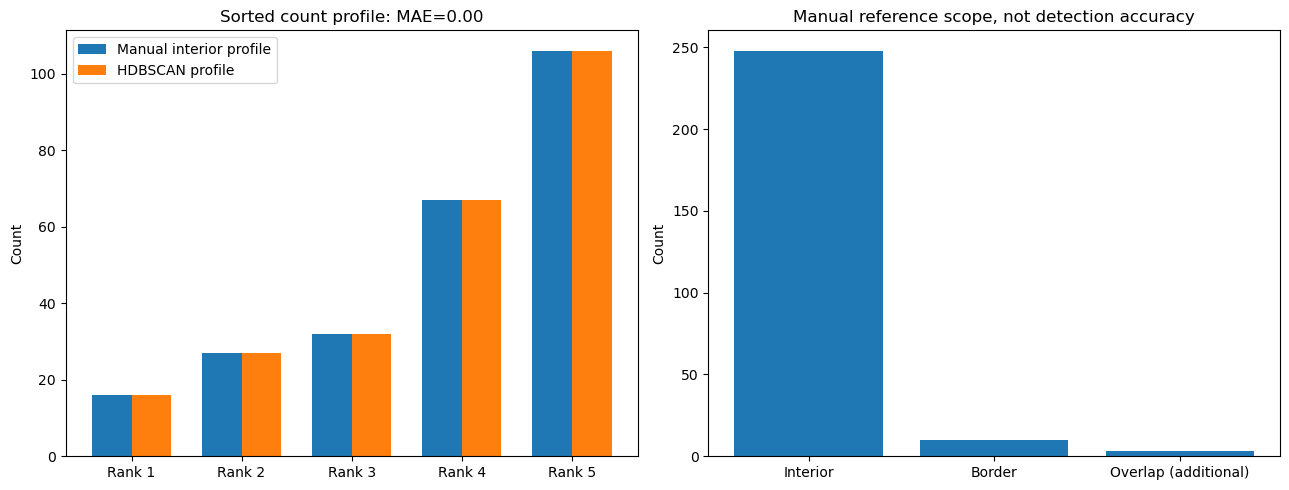

In [8]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
machine_profile = np.sort(pd.Series(labels[labels>=0]).value_counts().to_numpy())
if len(machine_profile)==len(reference_profile) and (labels>=0).all():
    positions = np.arange(len(reference_profile))
    axes[0].bar(positions-.18, reference_profile, .36, label='Manual interior profile')
    axes[0].bar(positions+.18, machine_profile, .36, label='HDBSCAN profile')
    axes[0].set_xticks(positions, [f'Rank {i+1}' for i in positions])
    error = np.abs(machine_profile-reference_profile)
    axes[0].set_title(f'Sorted count profile: MAE={error.mean():.2f}')
    axes[0].legend()
else:
    axes[0].text(.5,.5,'Five-group profile comparison not applicable',ha='center',wrap=True)
axes[0].set_ylabel('Count')
axes[1].bar(['Interior','Border','Overlap (additional)'],
            [reference.interior_count.sum(),reference.border_count.sum(),reference.overlap_additional_count.sum()])
axes[1].set(title='Manual reference scope, not detection accuracy', ylabel='Count')
fig.tight_layout(); fig.savefig(OUT/'count_reference_comparison.png',dpi=180); plt.show()


## 8. Optional object-level agreement and confusion matrix

For actual classification evaluation, independently fill `Notebooks/P3/manual_labels_alternative1.csv` with `object_id,true_label`. Use the original annotated image and spatial positions, not predictions or count matching. The existing section reports label coverage, ARI and NMI. Below, one-to-one Hungarian mapping aligns arbitrary cluster IDs to manual classes on the same labelled objects. Agreement is descriptive in-sample agreement, not held-out predictive accuracy. Unassigned and unmatched groups count as errors. Partial labels evaluate only those objects and may be biased. Missing detections require separate manual centre-point annotations and spatial matching; they cannot be measured from candidate labels alone.

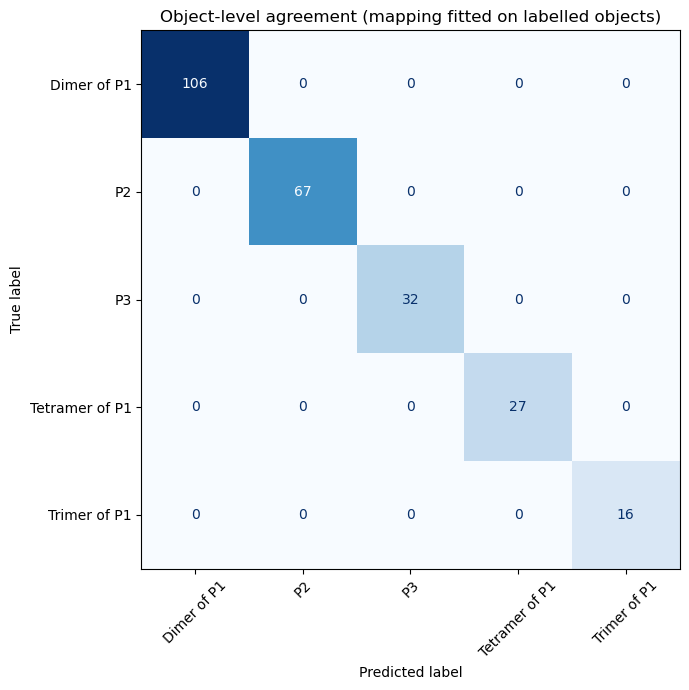

Precision / recall / F1: reviewed extracted candidates only


,precision,recall,f1-score,support
Class / average,,,,
Dimer of P1,1.000,1.000,1.000,106
P2,1.000,1.000,1.000,67
P3,1.000,1.000,1.000,32
Tetramer of P1,1.000,1.000,1.000,27
Trimer of P1,1.000,1.000,1.000,16
macro avg,1.000,1.000,1.000,248
weighted avg,1.000,1.000,1.000,248


,Metric,Value
0,Reviewed candidates,248.0
1,Correct after cluster-label alignment,248.0
2,Reviewed-candidate agreement,1.0
3,Annotation coverage of candidates,1.0
4,Macro F1,1.0


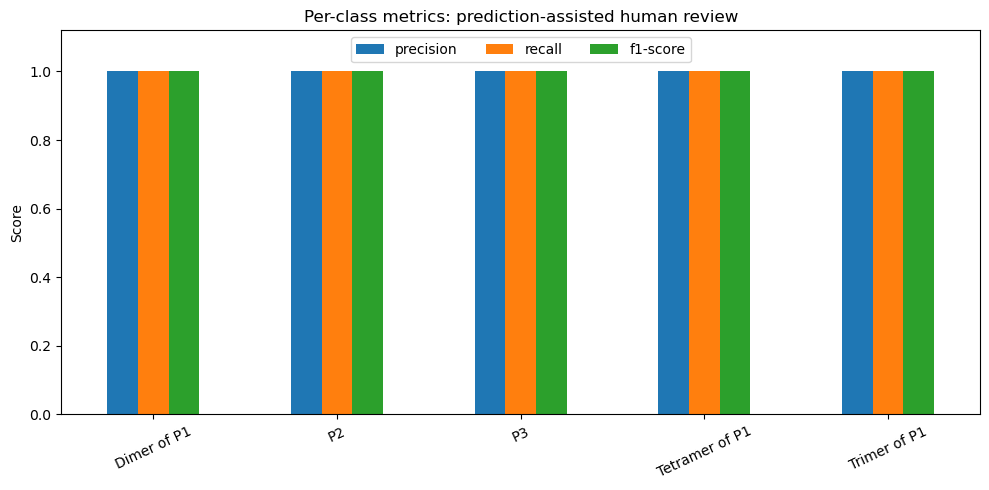

These metrics exclude 10 border objects and 3 overlapping objects not individually counted. They are not full-image detection recall or independent test accuracy.


In [9]:
if external:
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
    joined = pd.DataFrame({'object_id':ids,'predicted':labels}).merge(manual,on='object_id')
    ct = pd.crosstab(joined.loc[joined.predicted>=0,'predicted'], joined.loc[joined.predicted>=0,'true_label'])
    rr, cc = linear_sum_assignment(-ct.to_numpy()) if ct.size else ([],[])
    label_map = {ct.index[r]:str(ct.columns[c]) for r,c in zip(rr,cc)}
    predicted_names = joined.predicted.map(label_map).fillna('Unassigned / unmatched')
    names = sorted(set(joined.true_label.astype(str)) | set(predicted_names))
    matrix = confusion_matrix(joined.true_label.astype(str), predicted_names, labels=names)
    fig, ax = plt.subplots(figsize=(8,7))
    ConfusionMatrixDisplay(matrix, display_labels=names).plot(ax=ax,cmap='Blues',xticks_rotation=45,colorbar=False)
    ax.set_title('Object-level agreement (mapping fitted on labelled objects)')
    fig.tight_layout(); fig.savefig(OUT/'object_confusion_matrix.png',dpi=180); plt.show()
    report = classification_report(joined.true_label.astype(str), predicted_names, output_dict=True, zero_division=0)
    class_names = sorted(set(joined.true_label.astype(str)))
    report_table = pd.DataFrame({name: report[name] for name in class_names + ['macro avg', 'weighted avg']}).T
    report_table['support'] = report_table['support'].astype(int)
    report_table.index.name = 'Class / average'
    print('Precision / recall / F1: reviewed extracted candidates only')
    display(report_table.style.format({'precision':'{:.3f}', 'recall':'{:.3f}', 'f1-score':'{:.3f}', 'support':'{:d}'}))
    report_table.to_csv(OUT/'object_classification_report.csv')
    overview = pd.DataFrame({'Metric':['Reviewed candidates', 'Correct after cluster-label alignment', 'Reviewed-candidate agreement', 'Annotation coverage of candidates', 'Macro F1'],
        'Value':[len(joined), int((joined.true_label.astype(str).to_numpy() == predicted_names.to_numpy()).sum()),
                 float((joined.true_label.astype(str).to_numpy() == predicted_names.to_numpy()).mean()), len(joined)/len(ids), report['macro avg']['f1-score']]})
    display(overview)
    overview.to_csv(OUT/'object_evaluation_overview.csv',index=False)
    pd.DataFrame(matrix,index=names,columns=names).rename_axis('True label').to_csv(OUT/'object_confusion_matrix.csv')
    fig, ax = plt.subplots(figsize=(10,5))
    report_table.loc[class_names,['precision','recall','f1-score']].plot.bar(ax=ax,rot=25)
    ax.set(title='Per-class metrics: prediction-assisted human review',ylabel='Score',xlabel='',ylim=(0,1.12))
    ax.legend(loc='upper center',bbox_to_anchor=(.5,1.0),ncol=3)
    fig.tight_layout(); fig.savefig(OUT/'object_precision_recall_f1.png',dpi=180); plt.show()
    print('These metrics exclude 10 border objects and 3 overlapping objects not individually counted. They are not full-image detection recall or independent test accuracy.')
else:
    for filename in ['object_confusion_matrix.png','object_classification_report.csv','object_evaluation_overview.csv','object_confusion_matrix.csv','object_precision_recall_f1.png']:
        (OUT/filename).unlink(missing_ok=True)
    print('Object-level accuracy unavailable: independent per-object labels are required.')


## 9. Reproducibility checks

Confirm that P1 inputs are unchanged and all candidates, including noise, have exactly one assignment. Record relative paths, versions, parameters and input hashes.

In [10]:
assert input_hashes == {name:sha(P1/name) for name in INPUTS}
assert len(assignments)==len(ids) and assignments.object_id.is_unique
assert set(assignments.object_id)==set(ids)
manifest={'input_directory':str(P1.relative_to(ROOT)), 'input_hashes':input_hashes,
          'features':FEATURES,'configs':configs,'n_candidates':len(ids),
          'manual_labels_used_for_fitting':False,'sklearn':sklearn.__version__,
          'results':json.loads(summary.to_json(orient='records'))}
(OUT/'run_manifest.json').write_text(json.dumps(manifest,indent=2,allow_nan=False))
print('Verified: P1 unchanged; all candidates exported. Outputs:',OUT.relative_to(ROOT))


Verified: P1 unchanged; all candidates exported. Outputs: Notebooks/P3/outputs/alternative1_hdbscan_standalone


## 10. User-reviewed classification and full-image count coverage

Two separate denominators: classification agreement among the 248 reviewed candidates, and individually counted objects relative to the inclusive manual total of 261. The first is 100% according to the user's review; the second is 248/261 = 95.02%. Border exclusions are a deliberate preprocessing rule; overlapping molecules were not separately counted. Neither percentage establishes generalisation to other scans.

,class,reviewed_correct_count,border_count,overlap_additional_count,inclusive_count,count_recovery_fraction
0,Dimer of P1,106,8,0,114,0.929825
1,Trimer of P1,16,1,0,17,0.941176
2,Tetramer of P1,27,1,0,28,0.964286
3,P2,67,0,3,70,0.957143
4,P3,32,0,0,32,1.000000


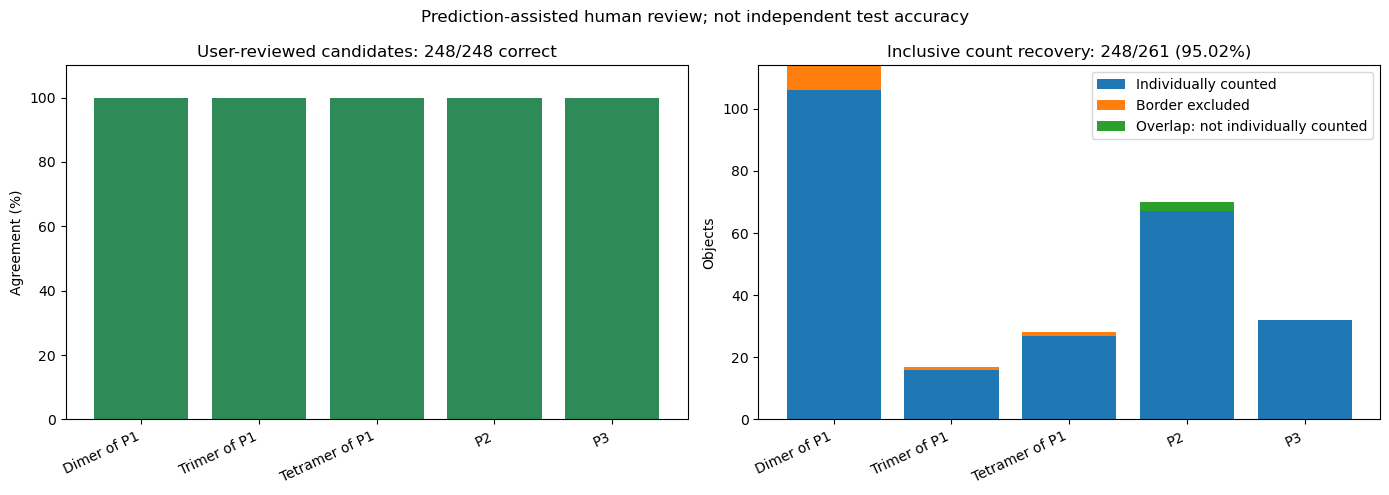

In [11]:
review_path = ROOT/'Notebooks/P3/manual_review_summary_alternative1.csv'
review = pd.read_csv(review_path)
assert review.reviewed_correct_count.sum() == len(ids)
display(review[['class','reviewed_correct_count','border_count','overlap_additional_count','inclusive_count','count_recovery_fraction']])
fig, axes = plt.subplots(1,2,figsize=(14,5))
positions = np.arange(len(review))
axes[0].bar(positions,100*review.reviewed_correct_count/review.interior_count,color='seagreen')
axes[0].set(ylim=(0,110), ylabel='Agreement (%)', title='User-reviewed candidates: 248/248 correct')
axes[1].bar(positions,review.interior_count,label='Individually counted')
axes[1].bar(positions,review.border_count,bottom=review.interior_count,label='Border excluded')
axes[1].bar(positions,review.overlap_additional_count,bottom=review.interior_count+review.border_count,label='Overlap: not individually counted')
axes[1].set(ylabel='Objects',title='Inclusive count recovery: 248/261 (95.02%)')
axes[1].legend()
for ax in axes:
    ax.set_xticks(positions,review['class'],rotation=25,ha='right')
fig.suptitle('Prediction-assisted human review; not independent test accuracy')
fig.tight_layout(); fig.savefig(OUT/'human_review_and_count_coverage.png',dpi=180); plt.show()
review.to_csv(OUT/'human_review_summary.csv',index=False)
